In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
train_path = Path("../../data/train.csv")
train_df = pd.read_csv(train_path)
train_df.head()

,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.949219,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.722656,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.601562,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.566406,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [3]:
train_df.columns

Index(['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject',
       'orientation', 'behavior', 'phase', 'gesture', 'acc_x',
       ...
       'tof_5_v54', 'tof_5_v55', 'tof_5_v56', 'tof_5_v57', 'tof_5_v58',
       'tof_5_v59', 'tof_5_v60', 'tof_5_v61', 'tof_5_v62', 'tof_5_v63'],
      dtype='object', length=341)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline


In [5]:
# Basic dataset exploration
print("Dataset Shape:", train_df.shape)
print("\n" + "="*50)
print("BASIC DATASET INFO")
print("="*50)

print(f"\nNumber of unique sequences: {train_df['sequence_id'].nunique()}")
print(f"Number of unique subjects: {train_df['subject'].nunique()}")
print(f"Number of unique gestures: {train_df['gesture'].nunique()}")

print("\nSequence types:")
print(train_df['sequence_type'].value_counts())

print("\nPhases:")
print(train_df['phase'].value_counts())

print("\nOrientations:")
print(train_df['orientation'].value_counts())

print("\nUnique gestures:")
unique_gestures = train_df['gesture'].unique()
for i, gesture in enumerate(unique_gestures):
    print(f"{i+1}. {gesture}")


Dataset Shape: (574945, 341)

BASIC DATASET INFO

Number of unique sequences: 8151
Number of unique subjects: 81
Number of unique gestures: 18

Sequence types:
sequence_type
Target        344058
Non-Target    230887
Name: count, dtype: int64

Phases:
phase
Transition    319128
Gesture       255817
Name: count, dtype: int64

Orientations:
orientation
Seated Straight                    188120
Seated Lean Non Dom - FACE DOWN    131636
Lie on Back                        130043
Lie on Side - Non Dominant         125146
Name: count, dtype: int64

Unique gestures:
1. Cheek - pinch skin
2. Forehead - pull hairline
3. Write name on leg
4. Feel around in tray and pull out an object
5. Neck - scratch
6. Neck - pinch skin
7. Eyelash - pull hair
8. Eyebrow - pull hair
9. Forehead - scratch
10. Above ear - pull hair
11. Wave hello
12. Write name in air
13. Text on phone
14. Pull air toward your face
15. Pinch knee/leg skin
16. Scratch knee/leg skin
17. Drink from bottle/cup
18. Glasses on/off


In [6]:
# Analyze sensor data structure
print("="*50)
print("SENSOR DATA ANALYSIS")
print("="*50)

# Separate different types of columns
metadata_cols = ['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject', 
                'orientation', 'behavior', 'phase', 'gesture']
acc_cols = [col for col in train_df.columns if col.startswith('acc_')]
rot_cols = [col for col in train_df.columns if col.startswith('rot_')]
thm_cols = [col for col in train_df.columns if col.startswith('thm_')]
tof_cols = [col for col in train_df.columns if col.startswith('tof_')]

print(f"Metadata columns: {len(metadata_cols)}")
print(f"Accelerometer columns: {len(acc_cols)} - {acc_cols}")
print(f"Rotation columns: {len(rot_cols)} - {rot_cols}")
print(f"Thermopile columns: {len(thm_cols)} - {thm_cols}")
print(f"Time-of-flight columns: {len(tof_cols)}")

# Check for missing values and -1 values (which indicate no sensor response)
print(f"\nMissing values in dataset: {train_df.isnull().sum().sum()}")

# Check -1 values in ToF sensors (indicating no sensor response)
tof_data = train_df[tof_cols]
total_tof_readings = tof_data.size
no_response_readings = (tof_data == -1).sum().sum()
print(f"ToF sensor readings with no response (-1): {no_response_readings:,} out of {total_tof_readings:,} ({no_response_readings/total_tof_readings*100:.1f}%)")

# Basic statistics for sensor data
print(f"\nSensor data ranges:")
sensor_cols = acc_cols + rot_cols + thm_cols
for col in sensor_cols:
    print(f"{col}: {train_df[col].min():.3f} to {train_df[col].max():.3f}")


SENSOR DATA ANALYSIS
Metadata columns: 9
Accelerometer columns: 3 - ['acc_x', 'acc_y', 'acc_z']
Rotation columns: 4 - ['rot_w', 'rot_x', 'rot_y', 'rot_z']
Thermopile columns: 5 - ['thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5']
Time-of-flight columns: 320

Missing values in dataset: 3597807
ToF sensor readings with no response (-1): 105,770,214 out of 183,982,400 (57.5%)

Sensor data ranges:
acc_x: -34.586 to 46.328
acc_y: -24.402 to 27.184
acc_z: -42.855 to 30.078
rot_w: 0.000 to 0.999
rot_x: -0.999 to 1.000
rot_y: -1.000 to 0.999
rot_z: -0.998 to 1.000
thm_1: -0.370 to 38.458
thm_2: 21.959 to 37.578
thm_3: 0.000 to 37.295
thm_4: 22.376 to 39.588
thm_5: 22.045 to 37.683


In [7]:
# Sequence analysis
print("="*50)
print("SEQUENCE STRUCTURE ANALYSIS")
print("="*50)

# Analyze sequence lengths
sequence_lengths = train_df.groupby('sequence_id')['sequence_counter'].max() + 1
print(f"Sequence length statistics:")
print(f"  Mean: {sequence_lengths.mean():.1f}")
print(f"  Std: {sequence_lengths.std():.1f}")
print(f"  Min: {sequence_lengths.min()}")
print(f"  Max: {sequence_lengths.max()}")

# Analyze phase distribution within sequences
phase_analysis = train_df.groupby(['sequence_id', 'phase']).size().unstack(fill_value=0)
print(f"\nPhase distribution across sequences:")
print(phase_analysis.describe())

# Check if all sequences have all three phases
phases_per_seq = (phase_analysis > 0).sum(axis=1)
print(f"\nSequences with all 3 phases: {(phases_per_seq == 3).sum()} out of {len(phases_per_seq)}")

# Sample a few sequences to understand the structure
sample_sequences = train_df['sequence_id'].unique()[:5]
print(f"\nSample sequence structures:")
for seq_id in sample_sequences:
    seq_data = train_df[train_df['sequence_id'] == seq_id][['sequence_counter', 'phase', 'behavior', 'gesture']].head(10)
    print(f"\n{seq_id}:")
    print(seq_data.to_string(index=False))


SEQUENCE STRUCTURE ANALYSIS
Sequence length statistics:
  Mean: 70.5
  Std: 35.4
  Min: 29
  Max: 700

Phase distribution across sequences:
phase      Gesture   Transition
count  8151.000000  8151.000000
mean     31.384738    39.152006
std       3.602887    34.663045
min       0.000000     4.000000
25%      30.000000    21.000000
50%      31.000000    28.000000
75%      32.000000    46.000000
max      71.000000   670.000000

Sequences with all 3 phases: 0 out of 8151

Sample sequence structures:

SEQ_000007:
 sequence_counter      phase                                  behavior            gesture
                0 Transition Relaxes and moves hand to target location Cheek - pinch skin
                1 Transition Relaxes and moves hand to target location Cheek - pinch skin
                2 Transition Relaxes and moves hand to target location Cheek - pinch skin
                3 Transition Relaxes and moves hand to target location Cheek - pinch skin
                4 Transition Relaxes

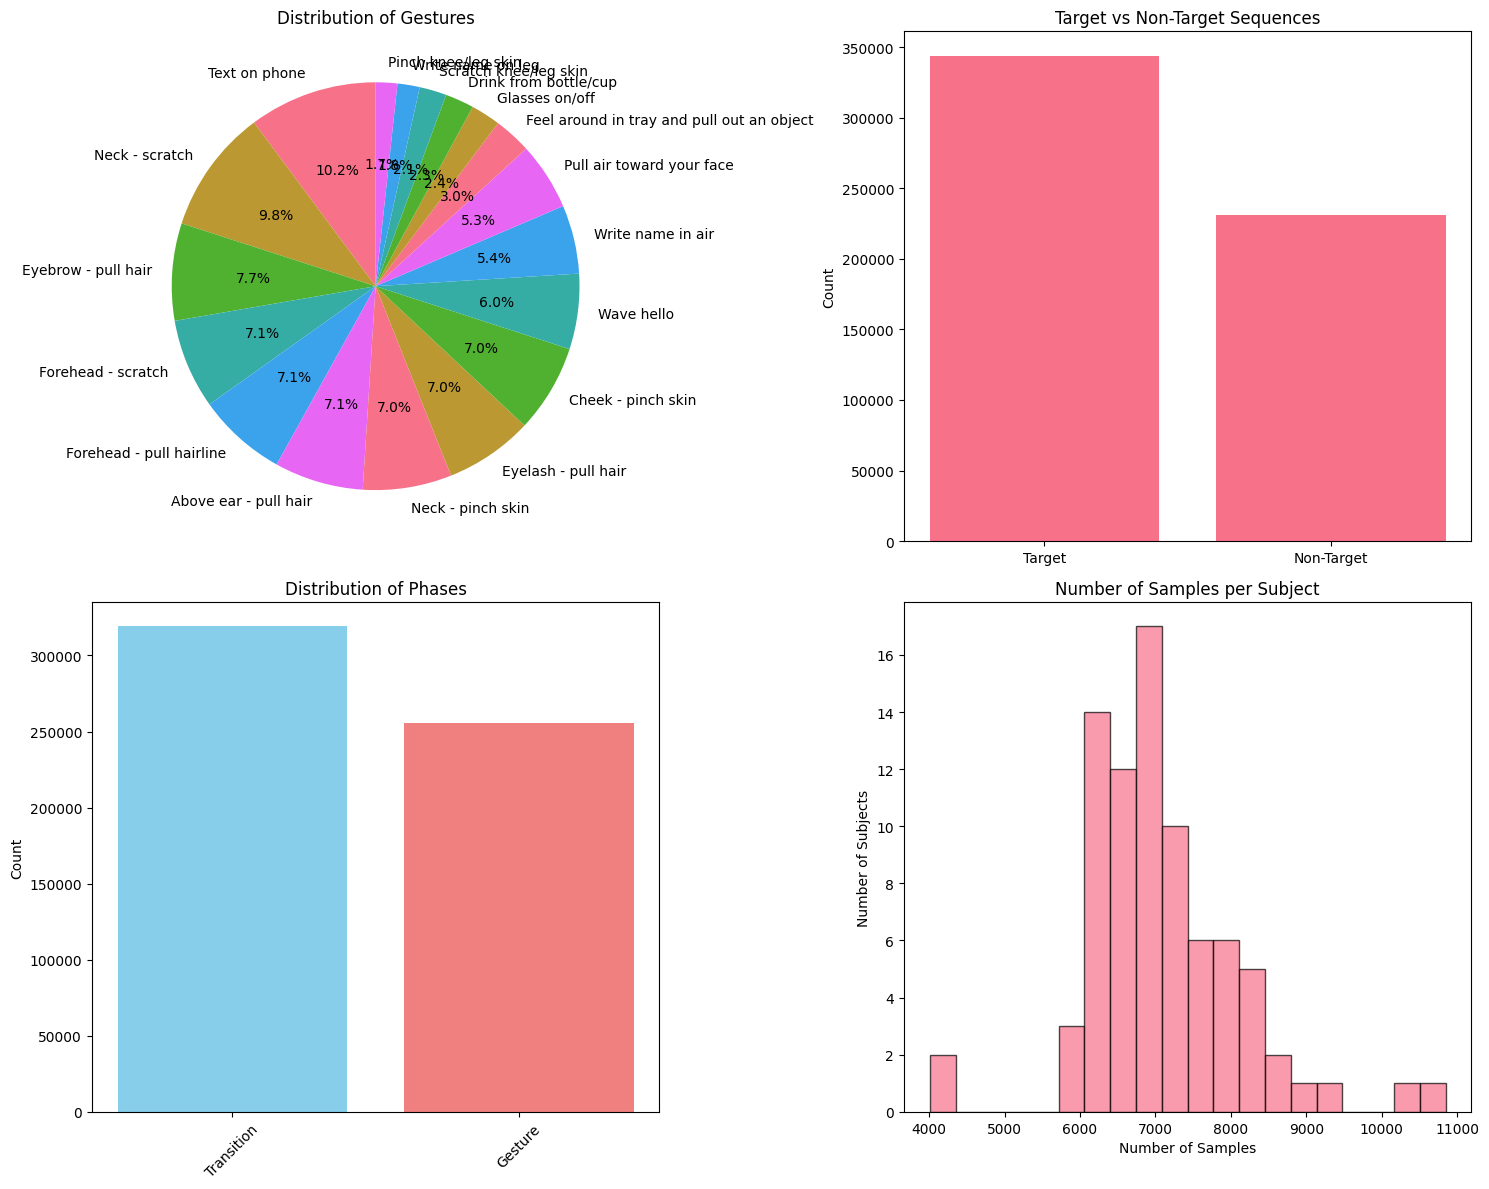

Gesture distribution details:
gesture
Text on phone                                 58462
Neck - scratch                                56619
Eyebrow - pull hair                           44305
Forehead - scratch                            40923
Forehead - pull hairline                      40802
Above ear - pull hair                         40560
Neck - pinch skin                             40507
Eyelash - pull hair                           40218
Cheek - pinch skin                            40124
Wave hello                                    34356
Write name in air                             31267
Pull air toward your face                     30743
Feel around in tray and pull out an object    17114
Glasses on/off                                13542
Drink from bottle/cup                         13093
Scratch knee/leg skin                         12328
Write name on leg                             10138
Pinch knee/leg skin                            9844
Name: count, dtype: int64


In [8]:
# Visualizations - Gesture Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gesture distribution
gesture_counts = train_df['gesture'].value_counts()
axes[0, 0].pie(gesture_counts.values, labels=gesture_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Distribution of Gestures')

# Sequence type distribution
seq_type_counts = train_df['sequence_type'].value_counts()
axes[0, 1].bar(seq_type_counts.index, seq_type_counts.values)
axes[0, 1].set_title('Target vs Non-Target Sequences')
axes[0, 1].set_ylabel('Count')

# Phase distribution
phase_counts = train_df['phase'].value_counts()
axes[1, 0].bar(phase_counts.index, phase_counts.values, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1, 0].set_title('Distribution of Phases')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Subject participation
subject_counts = train_df['subject'].value_counts()
axes[1, 1].hist(subject_counts.values, bins=20, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Number of Samples per Subject')
axes[1, 1].set_xlabel('Number of Samples')
axes[1, 1].set_ylabel('Number of Subjects')

plt.tight_layout()
plt.show()

print(f"Gesture distribution details:")
print(gesture_counts)


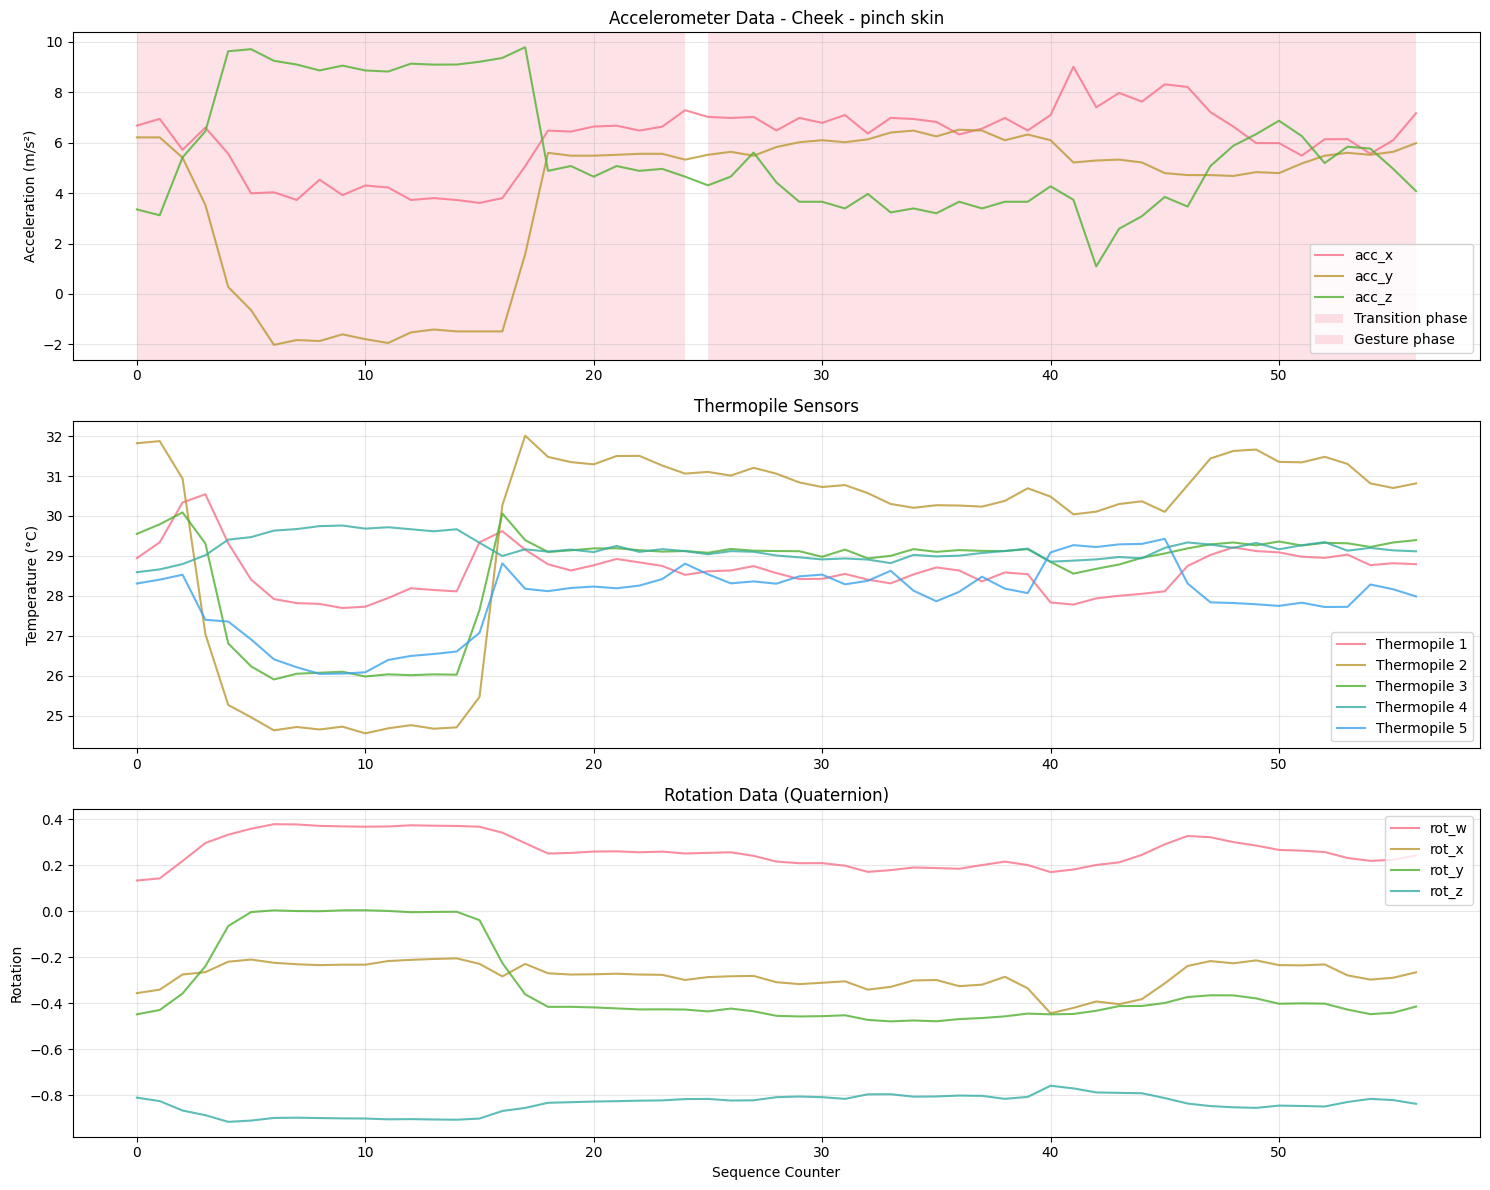

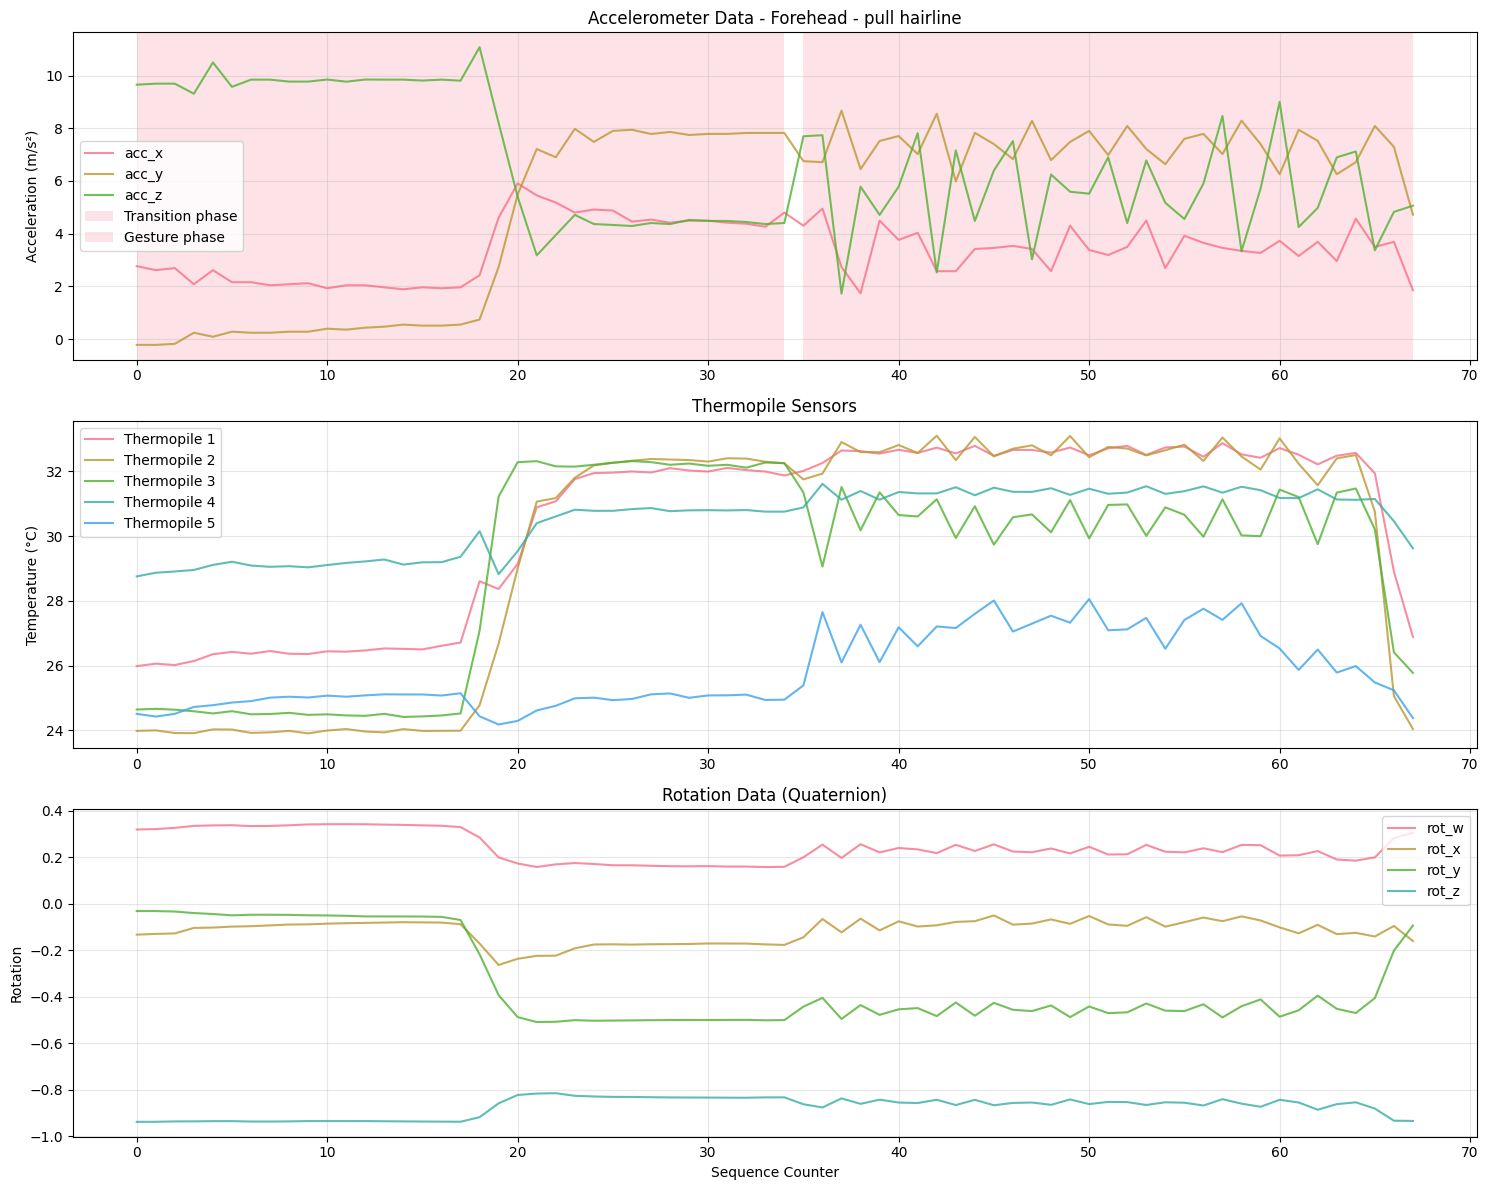

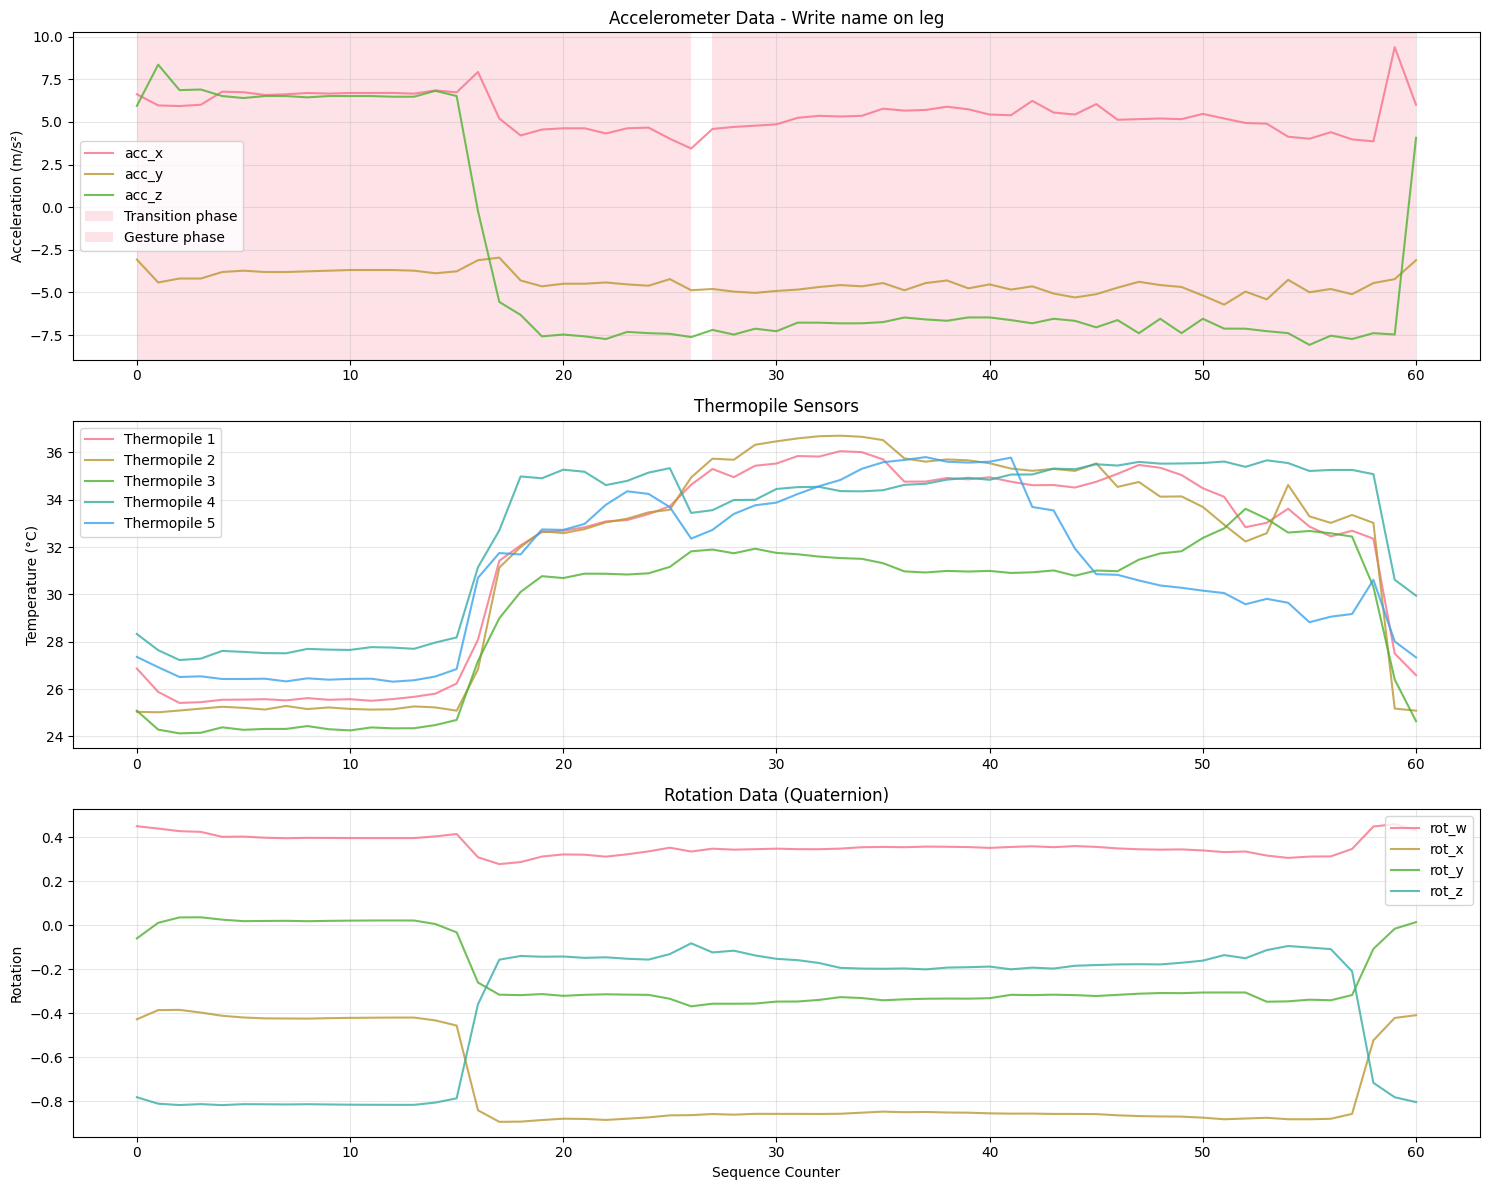

In [9]:
# Sensor data visualization over time
def plot_sensor_timeseries(sequence_id, gesture_name):
    """Plot time series data for a specific sequence"""
    seq_data = train_df[train_df['sequence_id'] == sequence_id].sort_values('sequence_counter')
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Accelerometer data
    axes[0].plot(seq_data['sequence_counter'], seq_data['acc_x'], label='acc_x', alpha=0.8)
    axes[0].plot(seq_data['sequence_counter'], seq_data['acc_y'], label='acc_y', alpha=0.8)
    axes[0].plot(seq_data['sequence_counter'], seq_data['acc_z'], label='acc_z', alpha=0.8)
    axes[0].set_title(f'Accelerometer Data - {gesture_name}')
    axes[0].set_ylabel('Acceleration (m/s²)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Color-code phases
    for phase in seq_data['phase'].unique():
        phase_data = seq_data[seq_data['phase'] == phase]
        if len(phase_data) > 0:
            axes[0].axvspan(phase_data['sequence_counter'].min(), 
                           phase_data['sequence_counter'].max(), 
                           alpha=0.2, label=f'{phase} phase')
    
    axes[0].legend()
    
    # Thermopile data
    thm_data = seq_data[thm_cols]
    for i, col in enumerate(thm_cols):
        axes[1].plot(seq_data['sequence_counter'], thm_data[col], label=f'Thermopile {i+1}', alpha=0.8)
    axes[1].set_title('Thermopile Sensors')
    axes[1].set_ylabel('Temperature (°C)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Rotation data
    axes[2].plot(seq_data['sequence_counter'], seq_data['rot_w'], label='rot_w', alpha=0.8)
    axes[2].plot(seq_data['sequence_counter'], seq_data['rot_x'], label='rot_x', alpha=0.8)
    axes[2].plot(seq_data['sequence_counter'], seq_data['rot_y'], label='rot_y', alpha=0.8)
    axes[2].plot(seq_data['sequence_counter'], seq_data['rot_z'], label='rot_z', alpha=0.8)
    axes[2].set_title('Rotation Data (Quaternion)')
    axes[2].set_ylabel('Rotation')
    axes[2].set_xlabel('Sequence Counter')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot a few example sequences for different gestures
sample_gestures = train_df['gesture'].unique()[:3]  # First 3 unique gestures
for gesture in sample_gestures:
    sample_seq = train_df[train_df['gesture'] == gesture]['sequence_id'].iloc[0]
    plot_sensor_timeseries(sample_seq, gesture)


Time-of-Flight Sensor Visualizations

Example 1: Cheek - pinch skin


TypeError: Image data of dtype object cannot be converted to float

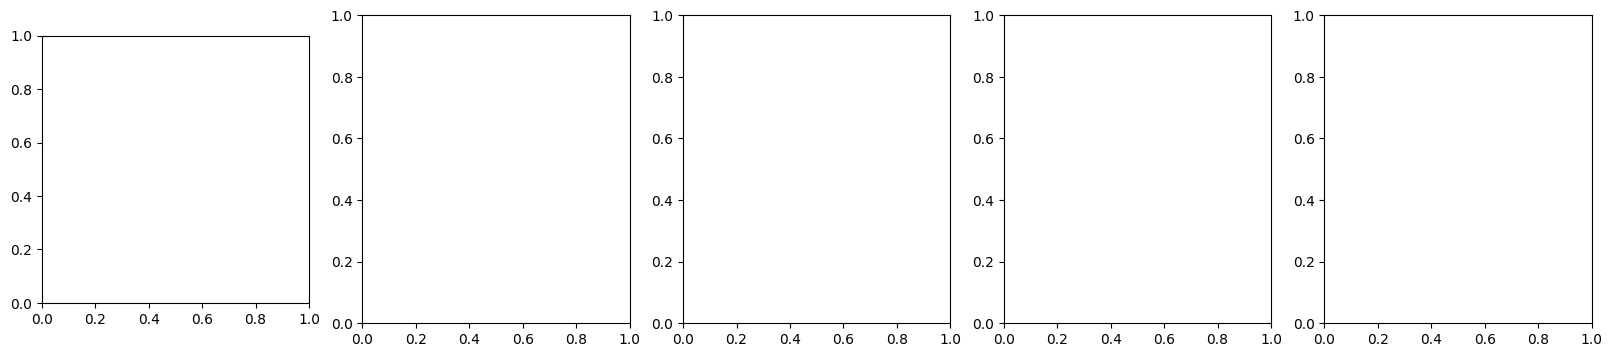

In [10]:
# Time-of-Flight sensor visualization (8x8 grid)
def visualize_tof_sensors(row_index, title_prefix=""):
    """Visualize ToF sensor data as 8x8 grids"""
    row_data = train_df.iloc[row_index]
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for sensor_idx in range(1, 6):  # ToF sensors 1-5
        # Extract the 64 values for this sensor
        tof_cols_sensor = [f'tof_{sensor_idx}_v{i}' for i in range(64)]
        tof_values = row_data[tof_cols_sensor].values
        
        # Reshape to 8x8 grid
        tof_grid = tof_values.reshape(8, 8)
        
        # Handle -1 values (no response) by setting them to 0 for visualization
        tof_grid_vis = np.where(tof_grid == -1, np.nan, tof_grid)
        
        # Create heatmap
        im = axes[sensor_idx-1].imshow(tof_grid_vis, cmap='viridis', aspect='equal')
        axes[sensor_idx-1].set_title(f'ToF Sensor {sensor_idx}')
        axes[sensor_idx-1].set_xlabel('Pixel X')
        axes[sensor_idx-1].set_ylabel('Pixel Y')
        
        # Add colorbar
        plt.colorbar(im, ax=axes[sensor_idx-1], fraction=0.046, pad=0.04)
    
    plt.suptitle(f'{title_prefix}ToF Sensors - Gesture: {row_data["gesture"]} | Phase: {row_data["phase"]}')
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    all_tof_values = []
    for sensor_idx in range(1, 6):
        tof_cols_sensor = [f'tof_{sensor_idx}_v{i}' for i in range(64)]
        sensor_values = row_data[tof_cols_sensor].values
        valid_values = sensor_values[sensor_values != -1]
        all_tof_values.extend(valid_values)
        
    if len(all_tof_values) > 0:
        print(f"ToF Statistics for this sample:")
        print(f"  Valid readings: {len(all_tof_values)}/320 ({len(all_tof_values)/320*100:.1f}%)")
        print(f"  Range: {np.min(all_tof_values):.1f} - {np.max(all_tof_values):.1f}")
        print(f"  Mean: {np.mean(all_tof_values):.1f}")

# Visualize ToF data for different gestures and phases
print("Time-of-Flight Sensor Visualizations")
print("="*50)

# Find examples of different gestures
for i, gesture in enumerate(train_df['gesture'].unique()[:3]):
    sample_idx = train_df[train_df['gesture'] == gesture].index[0]
    print(f"\nExample {i+1}: {gesture}")
    visualize_tof_sensors(sample_idx, f"Sample {i+1} - ")


Sensor Correlation Analysis


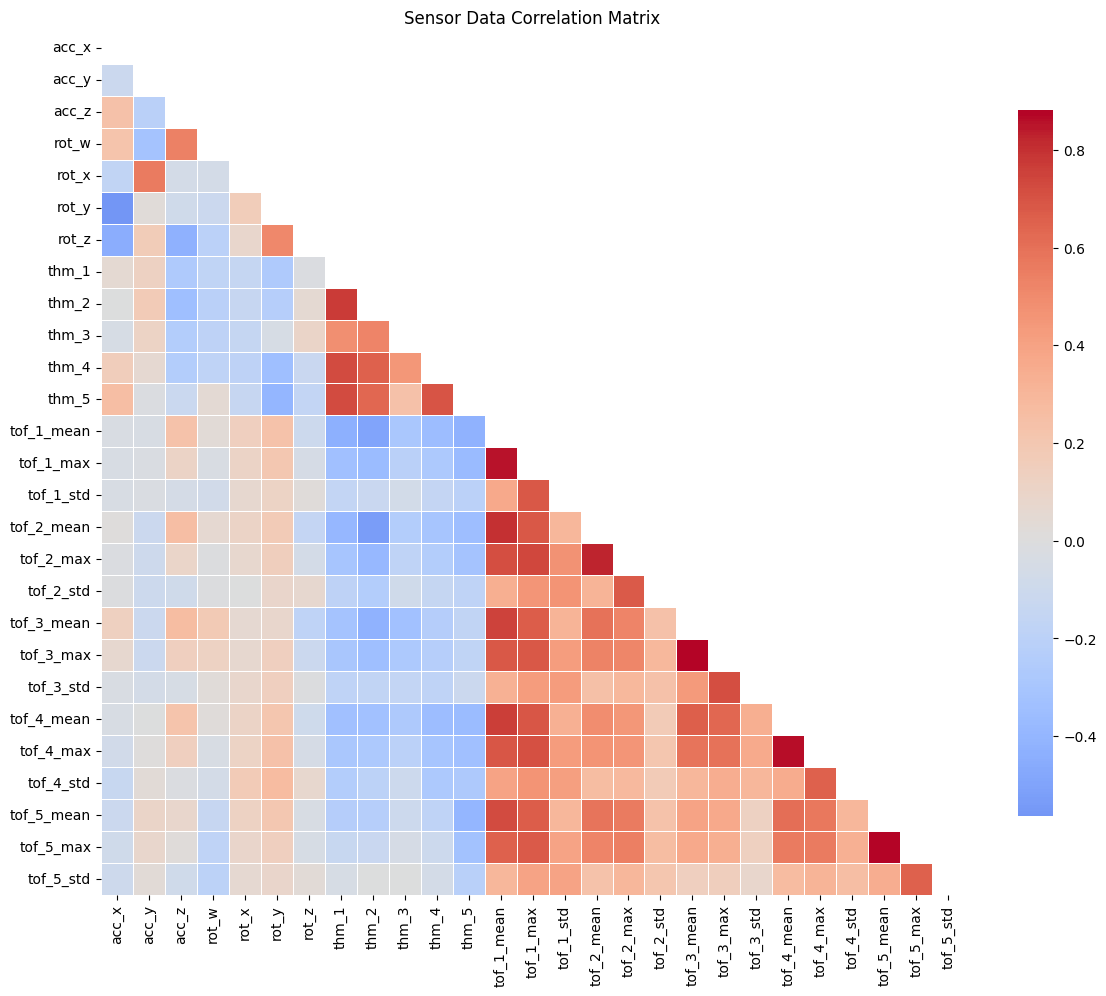


Strongest positive correlations (excluding self-correlations):
  tof_3_mean <-> tof_3_max: 0.881
  tof_5_mean <-> tof_5_max: 0.873
  tof_4_mean <-> tof_4_max: 0.863
  tof_1_mean <-> tof_1_max: 0.856
  tof_2_mean <-> tof_2_max: 0.827
  tof_1_mean <-> tof_2_mean: 0.800
  thm_1 <-> thm_2: 0.769
  tof_1_mean <-> tof_4_mean: 0.763
  tof_1_mean <-> tof_3_mean: 0.751
  tof_1_max <-> tof_2_max: 0.739


In [11]:
# Correlation analysis between sensor modalities
print("Sensor Correlation Analysis")
print("="*50)

# Sample a subset for correlation analysis (full dataset might be too large)
sample_size = min(10000, len(train_df))
sample_df = train_df.sample(n=sample_size, random_state=42)

# Compute correlations between different sensor types
sensor_data = sample_df[acc_cols + rot_cols + thm_cols].copy()

# Add some aggregated ToF features for correlation
for sensor_idx in range(1, 6):
    tof_cols_sensor = [f'tof_{sensor_idx}_v{i}' for i in range(64)]
    tof_data = sample_df[tof_cols_sensor]
    
    # Calculate mean, max, min for each ToF sensor (excluding -1 values)
    valid_tof = tof_data.replace(-1, np.nan)
    sensor_data[f'tof_{sensor_idx}_mean'] = valid_tof.mean(axis=1)
    sensor_data[f'tof_{sensor_idx}_max'] = valid_tof.max(axis=1)
    sensor_data[f'tof_{sensor_idx}_std'] = valid_tof.std(axis=1)

# Calculate correlation matrix
correlation_matrix = sensor_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Sensor Data Correlation Matrix')
plt.tight_layout()
plt.show()

# Show strongest correlations
print("\nStrongest positive correlations (excluding self-correlations):")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if not np.isnan(corr_val):
            corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
for sensor1, sensor2, corr in corr_pairs_sorted[:10]:
    print(f"  {sensor1} <-> {sensor2}: {corr:.3f}")


In [12]:
# Feature engineering and analysis for ML models
print("Feature Engineering Analysis")
print("="*50)

def extract_sequence_features(sequence_data):
    """Extract features from a sequence for ML models"""
    features = {}
    
    # Basic sequence info
    features['sequence_length'] = len(sequence_data)
    
    # Accelerometer features
    for axis in ['x', 'y', 'z']:
        col = f'acc_{axis}'
        features[f'acc_{axis}_mean'] = sequence_data[col].mean()
        features[f'acc_{axis}_std'] = sequence_data[col].std()
        features[f'acc_{axis}_max'] = sequence_data[col].max()
        features[f'acc_{axis}_min'] = sequence_data[col].min()
        features[f'acc_{axis}_range'] = sequence_data[col].max() - sequence_data[col].min()
    
    # Rotation features
    for comp in ['w', 'x', 'y', 'z']:
        col = f'rot_{comp}'
        features[f'rot_{comp}_mean'] = sequence_data[col].mean()
        features[f'rot_{comp}_std'] = sequence_data[col].std()
    
    # Thermopile features
    for i in range(1, 6):
        col = f'thm_{i}'
        features[f'thm_{i}_mean'] = sequence_data[col].mean()
        features[f'thm_{i}_std'] = sequence_data[col].std()
    
    # ToF features (aggregated)
    for sensor_idx in range(1, 6):
        tof_cols_sensor = [f'tof_{sensor_idx}_v{i}' for i in range(64)]
        tof_data = sequence_data[tof_cols_sensor]
        valid_tof = tof_data[tof_data != -1]
        
        if len(valid_tof) > 0:
            all_valid = valid_tof.values.flatten()
            features[f'tof_{sensor_idx}_mean'] = np.mean(all_valid)
            features[f'tof_{sensor_idx}_std'] = np.std(all_valid)
            features[f'tof_{sensor_idx}_max'] = np.max(all_valid)
            features[f'tof_{sensor_idx}_valid_ratio'] = len(all_valid) / (len(sequence_data) * 64)
        else:
            features[f'tof_{sensor_idx}_mean'] = 0
            features[f'tof_{sensor_idx}_std'] = 0
            features[f'tof_{sensor_idx}_max'] = 0
            features[f'tof_{sensor_idx}_valid_ratio'] = 0
    
    # Phase-based features
    phase_counts = sequence_data['phase'].value_counts()
    for phase in ['Transition', 'Pause', 'Gesture']:
        features[f'phase_{phase}_count'] = phase_counts.get(phase, 0)
        features[f'phase_{phase}_ratio'] = phase_counts.get(phase, 0) / len(sequence_data)
    
    return features

# Extract features for a sample of sequences
print("Extracting features for sample sequences...")
sample_sequences = train_df['sequence_id'].unique()[:100]  # Sample 100 sequences
sequence_features = []

for seq_id in sample_sequences:
    seq_data = train_df[train_df['sequence_id'] == seq_id]
    features = extract_sequence_features(seq_data)
    features['sequence_id'] = seq_id
    features['gesture'] = seq_data['gesture'].iloc[0]
    features['subject'] = seq_data['subject'].iloc[0]
    sequence_features.append(features)

features_df = pd.DataFrame(sequence_features)
print(f"Extracted {len(features_df)} feature vectors with {len(features_df.columns)-3} features each")

# Show feature importance via simple analysis
print(f"\nFeature statistics:")
print(features_df.describe())

# Show some sample features
print(f"\nSample feature names:")
feature_cols = [col for col in features_df.columns if col not in ['sequence_id', 'gesture', 'subject']]
print(feature_cols[:20])  # Show first 20 features


Feature Engineering Analysis
Extracting features for sample sequences...
Extracted 100 feature vectors with 60 features each

Feature statistics:
       sequence_length  acc_x_mean   acc_x_std   acc_x_max   acc_x_min  \
count       100.000000  100.000000  100.000000  100.000000  100.000000   
mean         71.110000    0.846149    3.456040    8.310508   -4.921523   
std          31.468084    4.606989    2.061876    4.938386    6.084754   
min          40.000000   -8.715194    0.335414   -7.203125  -17.003906   
25%          53.000000   -2.843695    1.725209    6.607422  -10.723633   
50%          59.000000    0.898968    3.000099    9.160156   -5.609375   
75%          81.000000    4.867802    5.130258   11.230469    0.265625   
max         234.000000    8.824139    7.813379   22.535156    6.890625   

       acc_x_range  acc_y_mean   acc_y_std   acc_y_max   acc_y_min  ...  \
count   100.000000  100.000000  100.000000  100.000000  100.000000  ...   
mean     13.232031    1.966760    3.2

In [13]:
# Analysis for RL applicability and tokenization considerations
print("="*60)
print("REINFORCEMENT LEARNING & TOKENIZATION ANALYSIS")
print("="*60)

print("""
REINFORCEMENT LEARNING APPLICABILITY:
====================================

1. TRADITIONAL CLASSIFICATION APPROACH:
   - This dataset is primarily designed for supervised classification
   - Target: Predict gesture from sensor sequences
   - Standard approach: CNN/RNN/Transformer architectures

2. RL APPLICABILITY CONSIDERATIONS:
   
   CHALLENGES for direct RL application:
   - No explicit reward signal in the data
   - No environment interaction or action-consequence pairs
   - Static dataset without dynamic environment feedback
   
   POTENTIAL RL APPLICATIONS:
   - Use as environment simulator for gesture prediction
   - Multi-armed bandit for gesture selection
   - Imitation learning from expert demonstrations
   - Sequence optimization for gesture recognition

3. RECOMMENDED APPROACH:
   - Start with supervised learning for baseline performance
   - Consider RL for optimization or active learning scenarios
   - Use RL for meta-learning across subjects or contexts

TOKENIZATION STRATEGY FOR SEQUENTIAL DATA:
=========================================
""")

# Analyze sequence structure for tokenization
print("Sequence Analysis for Tokenization:")

# Analyze temporal patterns
temporal_stats = []
for seq_id in train_df['sequence_id'].unique()[:50]:  # Sample analysis
    seq_data = train_df[train_df['sequence_id'] == seq_id].sort_values('sequence_counter')
    
    # Calculate change points in sensor data
    acc_magnitude = np.sqrt(seq_data['acc_x']**2 + seq_data['acc_y']**2 + seq_data['acc_z']**2)
    acc_changes = np.diff(acc_magnitude)
    significant_changes = np.sum(np.abs(acc_changes) > np.std(acc_changes))
    
    temporal_stats.append({
        'sequence_id': seq_id,
        'length': len(seq_data),
        'gesture': seq_data['gesture'].iloc[0],
        'phase_changes': len(seq_data['phase'].unique()),
        'acc_change_points': significant_changes,
        'gesture_phase_length': len(seq_data[seq_data['phase'] == 'Gesture'])
    })

temporal_df = pd.DataFrame(temporal_stats)

print(f"\nTemporal Structure Analysis:")
print(f"Average sequence length: {temporal_df['length'].mean():.1f} ± {temporal_df['length'].std():.1f}")
print(f"Average gesture phase length: {temporal_df['gesture_phase_length'].mean():.1f}")
print(f"Average acceleration change points: {temporal_df['acc_change_points'].mean():.1f}")

print(f"""
TOKENIZATION RECOMMENDATIONS:
=============================

1. TEMPORAL TOKENIZATION:
   - Window size: {int(temporal_df['length'].mean() // temporal_df['phase_changes'].mean())} timesteps per token
   - Overlap: 50% for better temporal continuity
   - Phase-aware: Separate tokens for Transition/Pause/Gesture phases

2. SENSOR MODALITY TOKENS:
   - IMU tokens: [acc_x, acc_y, acc_z, rot_w, rot_x, rot_y, rot_z]
   - Thermal tokens: [thm_1, thm_2, thm_3, thm_4, thm_5]
   - ToF tokens: Aggregate 8x8 grids to spatial features per sensor
   - Multi-modal fusion: Concatenate or use separate embedding layers

3. HIERARCHICAL TOKENIZATION:
   - Level 1: Raw sensor readings (high frequency)
   - Level 2: Aggregated features (medium frequency)
   - Level 3: Phase/gesture labels (low frequency)

4. FOR RL APPLICATIONS:
   - State representation: Tokenized sensor sequences
   - Action space: Gesture predictions or confidence scores
   - Reward: Accuracy, precision, recall metrics
   - Environment: Simulated sensor data stream

NEXT STEPS FOR MODEL DEVELOPMENT:
===============================
1. Implement CNN/RNN baseline for gesture classification
2. Experiment with Transformer architectures
3. Consider temporal attention mechanisms
4. Test multi-modal fusion strategies
5. Evaluate on different subjects (generalization)

For RL integration:
1. Design reward functions based on classification metrics
2. Create environment wrapper for sequence prediction
3. Implement policy gradient methods for sequence optimization
4. Consider curriculum learning across gesture complexities
""")

# Summary statistics
print(f"\nDATASET SUMMARY FOR ML/RL:")
print(f"- Total sequences: {train_df['sequence_id'].nunique():,}")
print(f"- Total gestures: {train_df['gesture'].nunique()}")
print(f"- Total subjects: {train_df['subject'].nunique()}")
print(f"- Average sequence length: {temporal_df['length'].mean():.0f} timesteps")
print(f"- Sensor modalities: 4 (IMU, Thermal, ToF, Metadata)")
print(f"- Feature dimensionality: {len(tof_cols) + len(acc_cols) + len(rot_cols) + len(thm_cols)} raw features")


REINFORCEMENT LEARNING & TOKENIZATION ANALYSIS

REINFORCEMENT LEARNING APPLICABILITY:

1. TRADITIONAL CLASSIFICATION APPROACH:
   - This dataset is primarily designed for supervised classification
   - Target: Predict gesture from sensor sequences
   - Standard approach: CNN/RNN/Transformer architectures

2. RL APPLICABILITY CONSIDERATIONS:

   CHALLENGES for direct RL application:
   - No explicit reward signal in the data
   - No environment interaction or action-consequence pairs
   - Static dataset without dynamic environment feedback

   POTENTIAL RL APPLICATIONS:
   - Use as environment simulator for gesture prediction
   - Multi-armed bandit for gesture selection
   - Imitation learning from expert demonstrations
   - Sequence optimization for gesture recognition

3. RECOMMENDED APPROACH:
   - Start with supervised learning for baseline performance
   - Consider RL for optimization or active learning scenarios
   - Use RL for meta-learning across subjects or contexts

TOKENIZATI

In [14]:
for name in train_df.columns:
    print(name)

row_id
sequence_type
sequence_id
sequence_counter
subject
orientation
behavior
phase
gesture
acc_x
acc_y
acc_z
rot_w
rot_x
rot_y
rot_z
thm_1
thm_2
thm_3
thm_4
thm_5
tof_1_v0
tof_1_v1
tof_1_v2
tof_1_v3
tof_1_v4
tof_1_v5
tof_1_v6
tof_1_v7
tof_1_v8
tof_1_v9
tof_1_v10
tof_1_v11
tof_1_v12
tof_1_v13
tof_1_v14
tof_1_v15
tof_1_v16
tof_1_v17
tof_1_v18
tof_1_v19
tof_1_v20
tof_1_v21
tof_1_v22
tof_1_v23
tof_1_v24
tof_1_v25
tof_1_v26
tof_1_v27
tof_1_v28
tof_1_v29
tof_1_v30
tof_1_v31
tof_1_v32
tof_1_v33
tof_1_v34
tof_1_v35
tof_1_v36
tof_1_v37
tof_1_v38
tof_1_v39
tof_1_v40
tof_1_v41
tof_1_v42
tof_1_v43
tof_1_v44
tof_1_v45
tof_1_v46
tof_1_v47
tof_1_v48
tof_1_v49
tof_1_v50
tof_1_v51
tof_1_v52
tof_1_v53
tof_1_v54
tof_1_v55
tof_1_v56
tof_1_v57
tof_1_v58
tof_1_v59
tof_1_v60
tof_1_v61
tof_1_v62
tof_1_v63
tof_2_v0
tof_2_v1
tof_2_v2
tof_2_v3
tof_2_v4
tof_2_v5
tof_2_v6
tof_2_v7
tof_2_v8
tof_2_v9
tof_2_v10
tof_2_v11
tof_2_v12
tof_2_v13
tof_2_v14
tof_2_v15
tof_2_v16
tof_2_v17
tof_2_v18
tof_2_v19
tof_2_v20
tof_2

Each tof1~5 has v1~v63